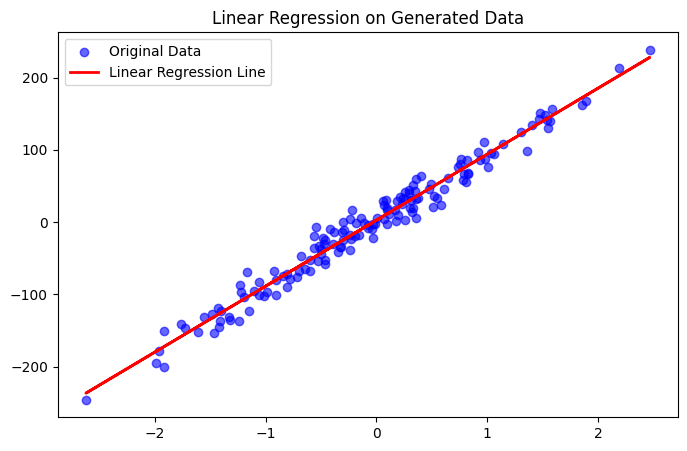

Mean Squared Error (MSE): 210.61
Mean Absolute Error (MAE): 11.81


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
from sklearn.model_selection import train_test_split

# Creatg data for training using make_regression
X, y = make_regression(n_samples=150, n_features=1, noise=15.0, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Original Data')

# 4. Creation and training the LinearRegression model
model_lr = LinearRegression()
model_lr.fit(X, y)

# Making predictions
y_pred = model_lr.predict(X)

plt.plot(X, y_pred, color='red', linewidth=2, label='Linear Regression Line')
plt.title('Linear Regression on Generated Data')
plt.legend()
plt.show()

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

The linear regression model identified the underlying trend in the dataset. The Mean Absolute Error indicates that the model's predictions deviate from the actual values by a relatively small margin, demonstrating a baseline fit for the generated data


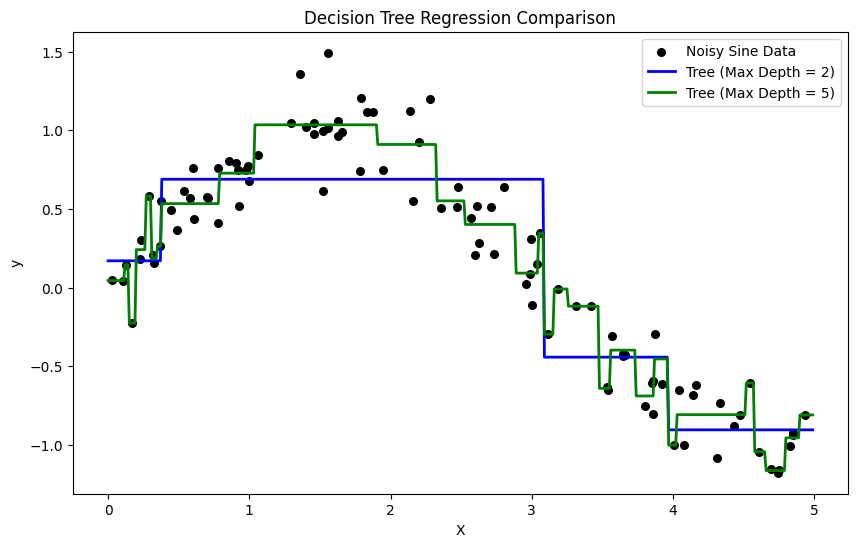

In [2]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_sin = np.sort(5 * np.random.rand(100, 1), axis=0)
# Create y values as sine of X plus some random noise
y_sin = np.sin(X_sin).ravel() + np.random.randn(100) * 0.2

tree_depth_2 = DecisionTreeRegressor(max_depth=2)
tree_depth_5 = DecisionTreeRegressor(max_depth=5)

tree_depth_2.fit(X_sin, y_sin)
tree_depth_5.fit(X_sin, y_sin)

X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred_2 = tree_depth_2.predict(X_test)
y_pred_5 = tree_depth_5.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X_sin, y_sin, s=30, color="black", label="Noisy Sine Data")
plt.plot(X_test, y_pred_2, color="blue", label="Tree (Max Depth = 2)", linewidth=2)
plt.plot(X_test, y_pred_5, color="green", label="Tree (Max Depth = 5)", linewidth=2)

plt.title("Decision Tree Regression Comparison")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

The decision tree models illustrate the trade-off between underfitting and overfitting. A shallow tree (max_depth=2) underfits the data, creating broad steps that fail to capture the underlying shape of the sine wave. In contrast, a deeper tree (max_depth=5) overfits the data by memorizing the random noise, resulting in a spiky and erratic prediction line rather than a smooth, generalizable curve

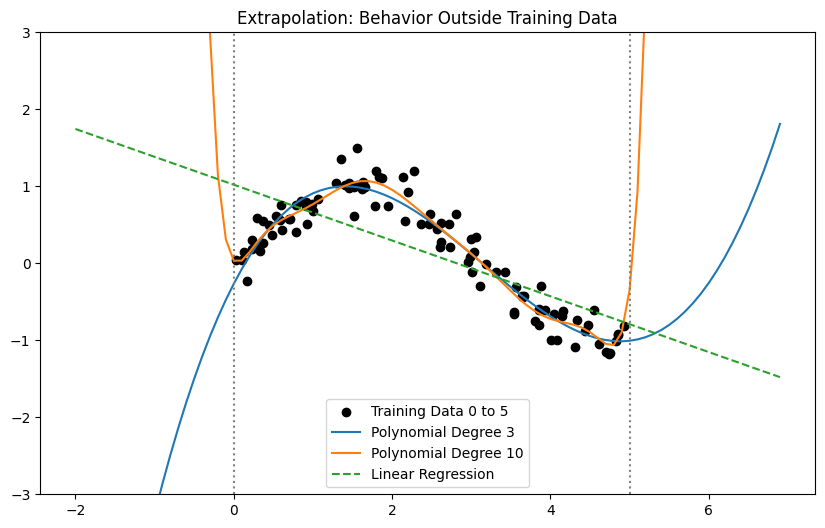

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create pipelines for polynomials of degree 3 and 10
poly_3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_10 = make_pipeline(PolynomialFeatures(degree=10), LinearRegression())

poly_3.fit(X_sin, y_sin)
poly_10.fit(X_sin, y_sin)
lr_extra = LinearRegression().fit(X_sin, y_sin)

X_extra = np.arange(-2.0, 7.0, 0.1)[:, np.newaxis]

plt.figure(figsize=(10, 6))
plt.scatter(X_sin, y_sin, color='black', label='Training Data 0 to 5')

plt.plot(X_extra, poly_3.predict(X_extra), label='Polynomial Degree 3')
plt.plot(X_extra, poly_10.predict(X_extra), label='Polynomial Degree 10')
plt.plot(X_extra, lr_extra.predict(X_extra), label='Linear Regression', linestyle='--')

plt.ylim(-3, 3)
plt.title("Extrapolation: Behavior Outside Training Data")
plt.axvline(0, color='gray', linestyle=':')
plt.axvline(5, color='gray', linestyle=':')
plt.legend()
plt.show()

This plot demonstrates the dangers of extrapolation. While the models fit the data reasonably well inside the training boundaries (between 0 and 5), their behavior outside this range is different. Linear regression extends predictably as a straight line, but the high-degree polynomials (especially degree 10) exhibit erratic spikes

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/alura-cursos/data-science-analise-exploratoria/main/Aula_0/tmdb_5000_movies.csv"
df = pd.read_csv(url)

df_clean = df[['budget', 'popularity', 'runtime', 'revenue']].dropna()
df_clean = df_clean[(df_clean['budget'] > 0) & (df_clean['revenue'] > 0)]

X_tmdb = df_clean[['budget', 'popularity', 'runtime']]
y_tmdb = df_clean['revenue']

X_train, X_test, y_train, y_test = train_test_split(X_tmdb, y_tmdb, test_size=0.2, random_state=42)

tmdb_model = LinearRegression()
tmdb_model.fit(X_train, y_train)

y_pred_tmdb = tmdb_model.predict(X_test)
mae_tmdb = mean_absolute_error(y_test, y_pred_tmdb)

print("TMDB Dataset Linear Regression Evaluation:")
print(f"On average, the model's revenue prediction is off by: ${mae_tmdb:,.2f}")

TMDB Dataset Linear Regression Evaluation:
On average, the model's revenue prediction is off by: $71,312,201.68


The Mean Absolute Error for the TMDB dataset appears exceptionally high. However this is expected due to the nature of the movie industry and the presence of mega-blockbusters with revenues crossing hundreds of millions or billions. A simple LinearRegression model struggle to predict these massive box office hits based on budget and popularity alone, as theatrical success is highly non-linear